<a href="https://colab.research.google.com/github/sathana495/Deep_Learning_projects/blob/main/Brain_Tumor_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import libraries**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**Mount Google Drive**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Check dataset**

In [ ]:
dataset_path = "/content/drive/MyDrive/dataset/Brain_Tumor_Datasets"

print("Dataset folders:")
print(os.listdir(dataset_path))

Dataset folders:
['test', 'train']


**Set train and test paths**

In [ ]:
train_path = "/content/drive/MyDrive/dataset/Brain_Tumor_Datasets/train"
test_path = "/content/drive/MyDrive/dataset/Brain_Tumor_Datasets/test"

print("Train path:", train_path)
print("Test path:", test_path)

Train path: /content/drive/MyDrive/dataset/Brain_Tumor_Datasets/train
Test path: /content/drive/MyDrive/dataset/Brain_Tumor_Datasets/test


**Check classes**

In [ ]:
print("Train classes:", os.listdir(train_path))
print("Test classes:", os.listdir(test_path))

Train classes: ['no', 'yes']
Test classes: ['yes', 'no']


**STEP 1 — Image preprocessing**

**Create ImageDataGenerators**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

**STEP 2 — Load images**

**Training data**

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 5619 images belonging to 2 classes.


**Validation data**

In [ ]:
val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1404 images belonging to 2 classes.


**Test data**

In [ ]:
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1764 images belonging to 2 classes.


**Check class mapping**

In [ ]:
print("Class mapping:")
print(train_data.class_indices)

Class mapping:
{'no': 0, 'yes': 1}


**STEP 3 — Display sample images**

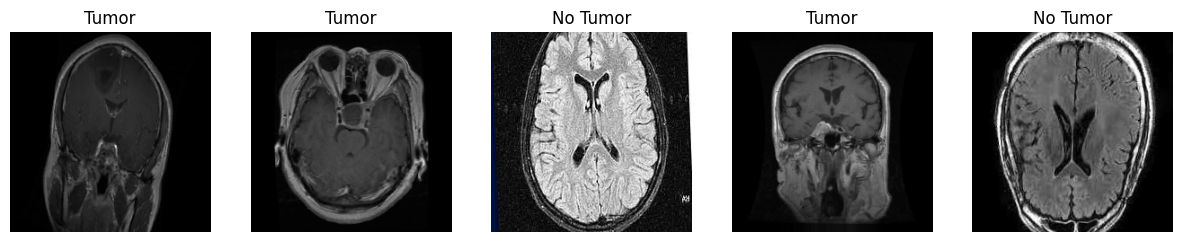

In [ ]:
images, labels = next(train_data)

plt.figure(figsize=(15, 5))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])

    if labels[i] == 1:
        plt.title("Tumor")
    else:
        plt.title("No Tumor")

    plt.axis("off")

plt.show()

**STEP 4 — Build CNN**

**CNN model**

In [ ]:
model = Sequential([

    # First convolution block
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(224, 224, 3)
    ),

    MaxPooling2D(pool_size=(2, 2)),


    # Second convolution block
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2, 2)),


    # Convert feature maps into a 1D vector
    Flatten(),


    # Fully connected layer
    Dense(
        units=128,
        activation='relu'
    ),


    # Reduce overfitting
    Dropout(0.5),


    # Binary classification
    Dense(
        units=1,
        activation='sigmoid'
    )
])

**STEP 5 — See model structure**

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

**STEP 6 — Compile model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/brain_tumor_cnn.keras"
)

print("✅ Trained model loaded successfully!")

✅ Trained model loaded successfully!


**STEP 7 — Train CNN**

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 121s 671ms/step - accuracy: 0.8658 - loss: 0.3445 - val_accuracy: 0.8077 - val_loss: 0.4627
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 113s 642ms/step - accuracy: 0.9420 - loss: 0.1687 - val_accuracy: 0.8853 - val_loss: 0.3245
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 114s 648ms/step - accuracy: 0.9438 - loss: 0.1474 - val_accuracy: 0.8390 - val_loss: 0.4498
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 112s 638ms/step - accuracy: 0.9523 - loss: 0.1278 - val_accuracy: 0.9031 - val_loss: 0.2771
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 110s 627ms/step - accuracy: 0.9532 - loss: 0.1206 - val_accuracy: 0.9160 - val_loss: 0.2126
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 130s 741ms/step - accuracy: 0.9537 - loss: 0.1189 - val_accuracy: 0.9131 - val_loss: 0.2171
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 111s 631ms/step - accuracy: 0.9571 - loss: 0.1136 - val_accuracy: 0.9152 - val_loss: 0.2002
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 112s 634ms/step - accuracy: 0.9566 -

**STEP 8 — Plot training performance**

**Accuracy**

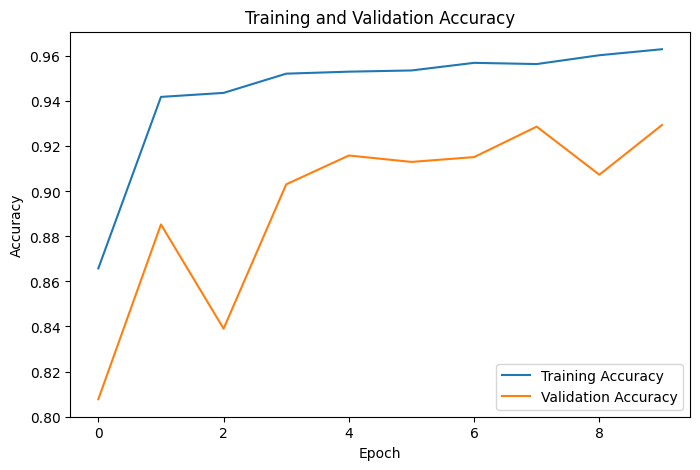

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

**Loss**

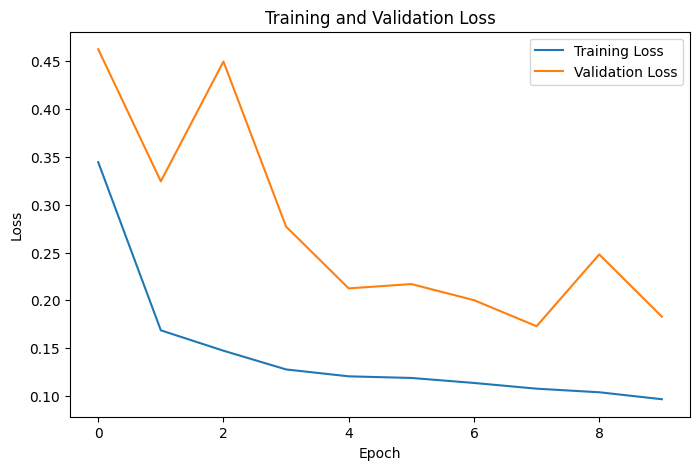

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**STEP 9 — Evaluate on untouched test data**

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

56/56 ━━━━━━━━━━━━━━━━━━━━ 1304s 24s/step - accuracy: 0.9598 - loss: 0.1256
Test Accuracy: 95.98%
Test Loss: 0.1256


**STEP 10 — Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

test_data.reset()

pred_prob = model.predict(test_data)

pred = (pred_prob >= 0.5).astype(int).flatten()

true = test_data.classes

cm = confusion_matrix(true, pred)

print("Confusion Matrix:")
print(cm)

56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step
Confusion Matrix:
[[708  21]
 [ 50 985]]


**Classification report**

In [ ]:
print("\nClassification Report:")

print(
    classification_report(
        true,
        pred,
        target_names=["No Tumor", "Tumor"]
    )
)


Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.93      0.97      0.95       729
       Tumor       0.98      0.95      0.97      1035

    accuracy                           0.96      1764
   macro avg       0.96      0.96      0.96      1764
weighted avg       0.96      0.96      0.96      1764



**STEP 11 — Display confusion matrix nicely**

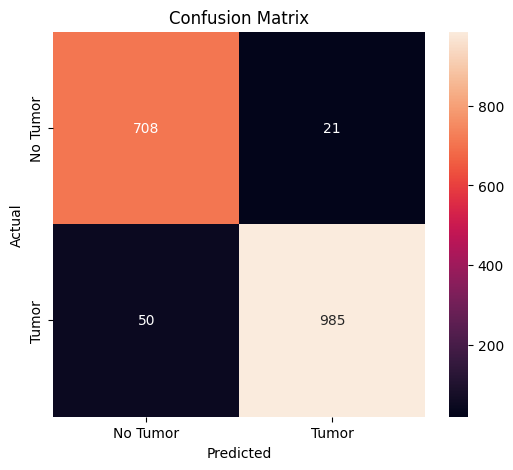

In [ ]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=["No Tumor", "Tumor"],
    yticklabels=["No Tumor", "Tumor"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**STEP 12 — Save the model**

In [ ]:
model.save(
    "/content/drive/MyDrive/brain_tumor_cnn.keras"
)

print("Model saved successfully!")

Model saved successfully!


**STEP 13 — Test one new MRI image**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-09-15 180644.png to Screenshot 2026-09-15 180644.png


**Predict the uploaded image**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

image_path = list(uploaded.keys())[0]

img = image.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

tumor_probability = prediction[0][0]

print(f"Tumor Probability: {tumor_probability:.4f}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Tumor Probability: 0.0000


In [ ]:
if tumor_probability >= 0.5:
    print(" Prediction: Tumor")
else:
    print("Prediction: No Tumor")

Prediction: No Tumor
